# Radio Interferometry Simulation with pyuvsim

This script performs radio interferometry simulations using pyuvsim and analyzes
the resulting visibility data. The workflow includes:

1. Path configuration and validation
2. Observation parameter inspection
3. Antenna layout visualization
4. Sky model loading and visualization
5. Frequency and time sampling analysis
6. UV coverage computation
7. Simulation execution with MPI
8. Visibility comparison and residual analysis

Author: Quentin Gueuning

Requirements: pyuvsim, pyuvdata, pyradiosky, healpy, astropy, numpy, matplotlib


## Imports



In [1]:
import os
import sys
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import combinations
import multiprocessing

import healpy as hp
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord

import pyuvsim
from pyuvsim import uvsim
from pyuvdata import UVData
from pyradiosky import SkyModel

## File Path Configuration


Automatically set up all necessary paths based on the project structure.  
The paths point to:

- Observation parameter YAML files  
- Telescope configuration files (layout, beam models)  
- Sky catalog files

Adjust `base_notebook` if the script is moved to a different location.


In [2]:
# Base folder of this notebook
base_notebook = "/home/qdg20/projects/sim_notebook"

# Project root (one level above notebook folder)
proj_root = os.path.normpath(os.path.join(base_notebook, ".."))

# Pyuvsim reference simulation folder
pyuvsim_root = os.path.join(proj_root, "pyuvsim", "reference_simulations", "first_generation")
telescope_cfg = os.path.join(pyuvsim_root, "telescope_config")
catalog_root = os.path.join(proj_root, "pyuvsim", "reference_simulations", "catalog_files")

# Paths to input files
OBSPARAM_YAML = os.path.join(pyuvsim_root, "fov-19.4-oscar-sm.yml")
TELESCOPE_LAYOUT_CSV = os.path.join(telescope_cfg, "hex-37-14.6m.csv")
BEAM_YAML = os.path.join(telescope_cfg, "hex-37-14.6m-gauss-fwhm9.3.yml")
SKYH5_PATH = os.path.join(catalog_root, "gleam-158.30-167.10-MHz-nf-38-pld-mean-2.82-std-0.19-fov-19.4deg-circ-field-1.skyh5")

# Verify and display paths
print("Paths set:")
print("obsparam:", OBSPARAM_YAML)
print("layout:", TELESCOPE_LAYOUT_CSV)
print("beam:", BEAM_YAML)
print("sky:", SKYH5_PATH)

Paths set:
obsparam: /home/qdg20/projects/pyuvsim/reference_simulations/first_generation/fov-19.4-oscar-sm.yml
layout: /home/qdg20/projects/pyuvsim/reference_simulations/first_generation/telescope_config/hex-37-14.6m.csv
beam: /home/qdg20/projects/pyuvsim/reference_simulations/first_generation/telescope_config/hex-37-14.6m-gauss-fwhm9.3.yml
sky: /home/qdg20/projects/pyuvsim/reference_simulations/catalog_files/gleam-158.30-167.10-MHz-nf-38-pld-mean-2.82-std-0.19-fov-19.4deg-circ-field-1.skyh5


## Helper Functions

Utility functions for file I/O and path resolution:

- `read_yaml`: Safe YAML file loader  
- `resolve_path`: Resolves relative paths with respect to the base directory


In [3]:
def read_yaml(path):
    """Load YAML file safely."""
    with open(path, 'r') as f:
        return yaml.safe_load(f)


def resolve_path(base_dir, path):
    """
    Resolve relative paths with respect to base_dir.
    Absolute paths are returned as-is.
    """
    if os.path.isabs(path):
        return path
    return os.path.normpath(os.path.join(base_dir, path))

## Observation Parameter Inspection

Load the observation parameter YAML file and display its structure.  
This file contains:

- Filing information (output paths)  
- Observation timing and frequency setup  
- Telescope configuration references  
- Sky model and catalog specifications  
- Beam model parameters


In [4]:
if not os.path.exists(OBSPARAM_YAML):
    print(f'WARNING: obsparam YAML not found at {OBSPARAM_YAML}.')
else:
    obsparam = read_yaml(OBSPARAM_YAML)
    print('Top-level keys in obsparam: ', list(obsparam.keys()))
    
    # Print helpful sections
    for key in ('filing', 'observation', 'telescope', 'sky_model', 'catalogs', 'beams'):
        if key in obsparam:
            print(f'\n--- {key} ---')
            print(yaml.dump(obsparam[key], default_flow_style=False))

Top-level keys in obsparam:  ['filing', 'freq', 'sources', 'telescope', 'time', 'select']

--- filing ---
clobber: true
outdir: results_data/
outfile_name: gleam-158.30-167.10-MHz-nf-38-pld-mean-2.82-std-0.19-fov-19.4deg-circ-field-1_quentin
output_format: uvh5


--- telescope ---
array_layout: telescope_config/hex-37-14.6m.csv
telescope_config_name: telescope_config/hex-37-14.6m-gauss-fwhm9.3.yml



## Antenna Layout Visualization

Parse the telescope layout CSV file and visualize antenna positions in  
East-North-Up (ENU) coordinates. The layout file contains columns:  
`Name, Number, BeamID, E, N, U`

Reading layout CSV: /home/qdg20/projects/pyuvsim/reference_simulations/first_generation/telescope_config/hex-37-14.6m.csv
Parsed 37 antennas


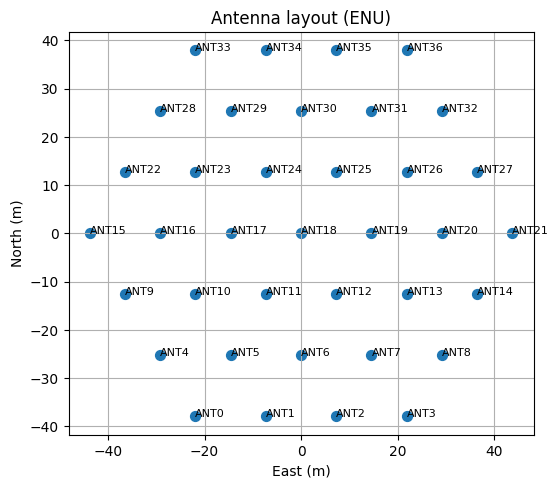

In [5]:
if os.path.exists(TELESCOPE_LAYOUT_CSV):
    print('Reading layout CSV:', TELESCOPE_LAYOUT_CSV)

    # Load CSV with tab delimiter
    data = np.genfromtxt(TELESCOPE_LAYOUT_CSV, delimiter='\t', dtype=None, 
                         names=True, encoding='utf-8')

    # Extract antenna positions
    names = data['Name']
    east = data['E']
    north = data['N']
    up = data['U']

    print(f'Parsed {len(east)} antennas')

    # Plot antenna layout in ENU frame
    plt.figure(figsize=(6, 6))
    plt.scatter(east, north, s=50)
    for i, n in enumerate(names):
        plt.text(east[i], north[i], n, fontsize=8)
    plt.xlabel('East (m)')
    plt.ylabel('North (m)')
    plt.title('Antenna layout (ENU)')
    plt.gca().set_aspect('equal', 'box')
    plt.grid(True)
    plt.show()

else:
    print('Layout CSV not found. Check TELESCOPE_LAYOUT_CSV path.')

## Beam Configuration
### GaussianBeam width conventions: electric field vs power

In the `GaussianBeam` function of the analytic_beam class in the pyuvdata package, the beam is fundamentally modeled at the level of the
electric field (voltage response), not directly at the level of power.

The analytic Gaussian beam is defined as an electric-field (voltage) pattern:

$$
E(\theta) = E_0 \exp\!\left(-\frac{\theta^2}{2\sigma_E^2}\right)
$$

where $\theta$ is the zenith angle and $\sigma_E$ is the electric-field standard deviation.
The corresponding power beam is:

$$
P(\theta) = |E(\theta)|^2
          = P_0 \exp\!\left(-\frac{\theta^2}{\sigma_E^2}\right)
$$

This is also a Gaussian, but with a smaller standard deviation:

$$
\sigma_P = \frac{\sigma_E}{\sqrt{2}}
$$

Thus, the power beam is narrower than the electric-field beam and half-power beam width (HBPW / FWHM) is defined on $P(\theta)$, not $E(\theta)$

### Relation between FWHM and σ

For any Gaussian:

$$
\mathrm{FWHM} = 2\sqrt{2\ln 2}\,\sigma \approx 2.355\,\sigma
$$

So for the power beam:

$$
\sigma_P = \frac{\mathrm{FWHM}}{2.355}
$$

and for the electric field:

$$
\sigma_E = \sqrt{2}\,\sigma_P
$$

### Example: HERA's primary beam at 150 MHz

Load and display beam YAML. We'll print the std of the Gaussian beam.

In [6]:
if os.path.exists(BEAM_YAML):
    beamcfg = read_yaml(BEAM_YAML)
    print('Beam YAML contents:')
    print(yaml.dump(beamcfg))
else:
    print('Beam YAML not found at', BEAM_YAML)

Beam YAML contents:
beam_paths:
  0:
    sigma: 0.09754450727124656
    type: gaussian
telescope_location: (-30.72152777777791, 21.428305555555557, 1073.0000000093132)
telescope_name: Hex37-14.6m



In [8]:
# -------------------------------
# Beam YAML sigma (electric-field)
# -------------------------------
sigma_field_rad = beamcfg['beam_paths'][0]['sigma']
sigma_field_deg = np.rad2deg(sigma_field_rad)

# -------------------------------
# Compute corresponding power beam sigma
# -------------------------------
# sigma_P = sigma_E / sqrt(2)
sigma_power_rad = sigma_field_rad / np.sqrt(2)
sigma_power_deg = np.rad2deg(sigma_power_rad)

# -------------------------------
# Compute FWHM of power beam
# FWHM = 2*sqrt(2*ln2)*sigma
# -------------------------------
fwhm_factor = 2 * np.sqrt(2 * np.log(2))
FWHM_power_rad = sigma_power_rad * fwhm_factor
FWHM_power_deg = sigma_power_deg * fwhm_factor

# -------------------------------
# Print results
# -------------------------------
print("=== Beam width from YAML sigma (electric-field) ===")
print(f"Electric-field sigma       : {sigma_field_deg:.2f} deg  ({sigma_field_rad:.4f} rad)")
print(f"Power-beam sigma           : {sigma_power_deg:.2f} deg  ({sigma_power_rad:.4f} rad)")
print(f"Power-beam FWHM (HBPW)     : {FWHM_power_deg:.2f} deg  ({FWHM_power_rad:.4f} rad)")


=== Beam width from YAML sigma (electric-field) ===
Electric-field sigma       : 5.59 deg  (0.0975 rad)
Power-beam sigma           : 3.95 deg  (0.0690 rad)
Power-beam FWHM (HBPW)     : 9.31 deg  (0.1624 rad)


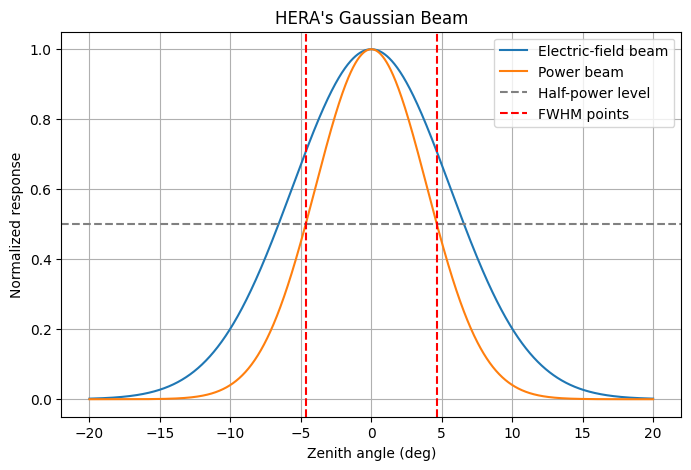

In [11]:
    # -------------------------------
    # Plot Gaussian beams
    # -------------------------------
    theta_deg = np.linspace(-20, 20, 2000)  # angle grid in degrees
    theta_rad = np.deg2rad(theta_deg)
    
    E = np.exp(-theta_rad**2 / (2 * sigma_field_rad**2))  # electric-field beam
    P = E**2                                               # power beam
    
    # Half-power points for power beam
    half_power = 0.5
    indices = np.where(P >= half_power)[0]
    theta_minus = theta_deg[indices[0]]
    theta_plus = theta_deg[indices[-1]]
    
    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(theta_deg, E, label='Electric-field beam')
    plt.plot(theta_deg, P, label='Power beam')
    plt.axhline(0.5, color='gray', linestyle='--', label='Half-power level')
    plt.axvline(theta_minus, color='red', linestyle='--', label='FWHM points')
    plt.axvline(theta_plus, color='red', linestyle='--')
    
    plt.xlabel("Zenith angle (deg)")
    plt.ylabel("Normalized response")
    plt.title("HERA's Gaussian Beam")
    plt.legend()
    plt.grid(True)
    plt.show()

## Sky Model Visualization


Load the sky model catalog in SKYH5 format and visualize source positions  
in equatorial coordinates (RA/Dec). 

Found sky file at /home/qdg20/projects/pyuvsim/reference_simulations/catalog_files/gleam-158.30-167.10-MHz-nf-38-pld-mean-2.82-std-0.19-fov-19.4deg-circ-field-1.skyh5
Number of sources: 4625


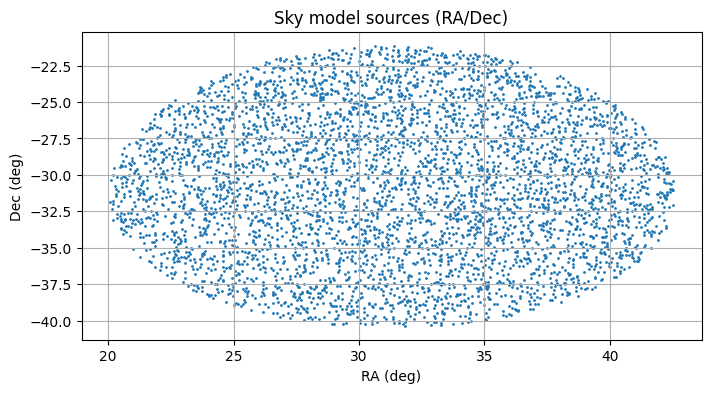

In [48]:
# Verify sky file exists
sky_present = os.path.exists(SKYH5_PATH)
if sky_present:
    print('Found sky file at', SKYH5_PATH)

    # Load SkyModel from HDF5
    skym = SkyModel()
    skym.read_skyh5(SKYH5_PATH)
    print('Number of sources:', skym.Ncomponents)

    # Extract source coordinates
    ra, dec = skym.get_lon_lat()
    ra_deg = ra.to('deg').value
    dec_deg = dec.to('deg').value

    # Plot source distribution on sky
    plt.figure(figsize=(8, 4))
    plt.scatter(ra_deg, dec_deg, s=1)
    plt.xlabel('RA (deg)')
    plt.ylabel('Dec (deg)')
    plt.title('Sky model sources (RA/Dec)')
    plt.grid(True)
    plt.show()
else:
    print('Sky file not found, create a dummy catalogue instead.')

## Frequency Array Visualization


Plot the frequency channels used in the simulation.


Number of frequency channels: 38


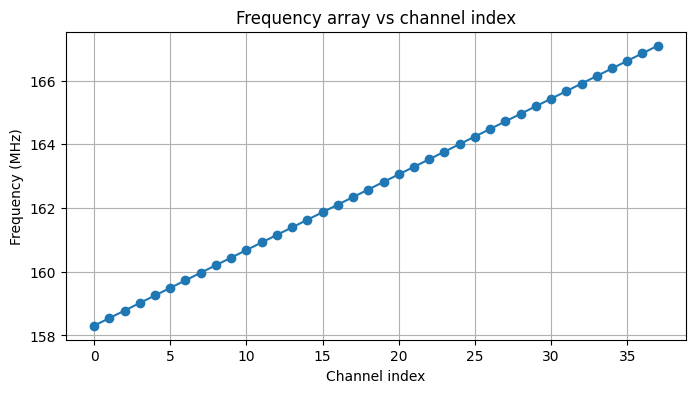

In [49]:
if obsparam and 'freq' in obsparam:
    f = obsparam['freq']
    N = int(f['Nfreqs'])
    start = f['start_freq']
    chanw = f['channel_width']
    
    # Compute frequency array
    freqs = start + chanw * np.arange(N)

    print(f'Number of frequency channels: {len(freqs)}')

    # Plot frequency vs channel index
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(freqs)), freqs / 1e6, marker='o', color='C0')
    plt.xlabel('Channel index')
    plt.ylabel('Frequency (MHz)')
    plt.title('Frequency array vs channel index')
    plt.grid(True)
    plt.show()
else:
    print("No frequency information found in obsparam.")

## Observation Time Array


Visualize the time sampling of the observation. Times are stored as Julian  
Dates (JD) and converted to UTC for display.

Number of time samples: 34


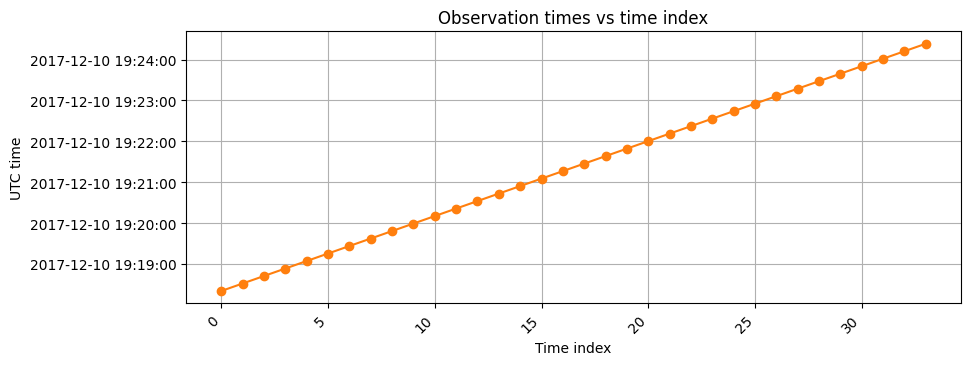

In [50]:
if obsparam and 'time' in obsparam and 'time_array' in obsparam['time']:
    times = np.array(obsparam['time']['time_array'])
    times_utc = Time(times, format='jd').to_datetime()
    print(f'Number of time samples: {len(times_utc)}')

    # Plot time array with proper UTC formatting
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(np.arange(len(times_utc)), times_utc, marker='o', color='C1')

    ax.set_xlabel('Time index')
    ax.set_ylabel('UTC time')
    ax.set_title('Observation times vs time index')
    ax.grid(True)

    # Format y-axis as full datetime
    ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
    fig.autofmt_xdate(rotation=45)

    plt.show()
else:
    print("No time array found in obsparam.")

## UV-Plane Coverage

Plot the (u, v) positions of selected baselines in the UV plane.  

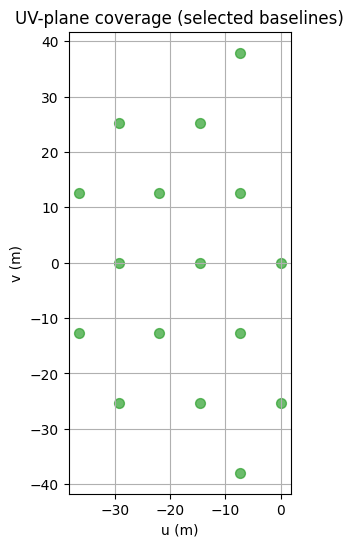

In [51]:
# Extract selected baselines from obsparam
sel_bls = []
if obsparam and 'select' in obsparam and 'bls' in obsparam['select']:
    sel_bls = eval(obsparam['select']['bls'])

if sel_bls:
    # Compute baseline vectors
    bls = np.array([[east[i] - east[j], north[i] - north[j]] for i, j in sel_bls])

    # Plot UV coverage
    plt.figure(figsize=(6, 6))
    plt.scatter(bls[:, 0], bls[:, 1], s=50, color='C2', alpha=0.7)
    plt.xlabel('u (m)')
    plt.ylabel('v (m)')
    plt.title('UV-plane coverage (selected baselines)')
    plt.grid(True)
    plt.gca().set_aspect('equal')
    plt.show()
else:
    print("No selected baselines defined in obsparam.")

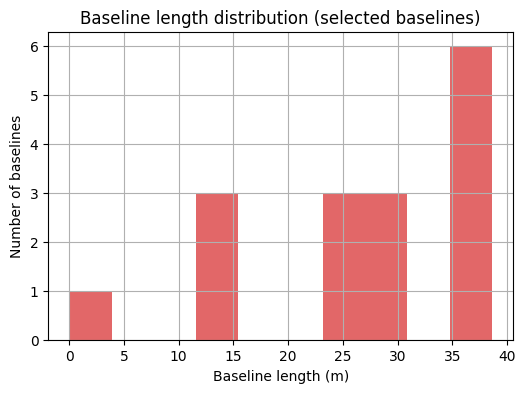

In [52]:
if sel_bls:
    # Compute baseline lengths
    bl_lengths = np.linalg.norm(bls, axis=1)

    # Plot histogram of baseline lengths
    plt.figure(figsize=(6, 4))
    plt.hist(bl_lengths, bins=10, color='C3', alpha=0.7)
    plt.xlabel('Baseline length (m)')
    plt.ylabel('Number of baselines')
    plt.title('Baseline length distribution (selected baselines)')
    plt.grid(True)
    plt.show()

## Simulation Execution

Run the pyuvsim simulation using MPI for parallel processing.  
The simulation computes complex visibilities for each baseline, time,  
frequency, and polarization based on the sky model and instrument configuration.

In [53]:
# Determine number of MPI processes (cap at 8)
nproc = min(multiprocessing.cpu_count(), 8)

# Path to pyuvsim simulation script
script_path = os.path.join(proj_root, "pyuvsim", "scripts", "run_param_pyuvsim.py")

print(f"Running pyuvsim with {nproc} MPI processes...")
print(f"Using script: {script_path}")
print(f"Using obsparam YAML: {OBSPARAM_YAML}")

# Execute simulation with MPI
get_ipython().system('mpirun -np {nproc} python3 {script_path} {OBSPARAM_YAML} | tee run.log')

Running pyuvsim with 8 MPI processes...
Using script: /home/qdg20/projects/pyuvsim/scripts/run_param_pyuvsim.py
Using obsparam YAML: /home/qdg20/projects/pyuvsim/reference_simulations/first_generation/fov-19.4-oscar-sm.yml


69265.61s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


The default baseline conjugation convention has changed. In the past it was 'ant2<ant1', it now defaults to 'ant1<ant2'. You can specify the baseline conjugation convention in `obs_param` by setting the obs_param['ordering']['conjugation_convention'] field. This warning will go away in version 1.5.
UVData initialization took 0.022 min
Skymodel setup took 0.000 min
Nbls: 16
Ntimes: 34
Nfreqs: 38
Nsrcs: 4625
Tasks:  20672.0
1.00% completed. 0:00:00.229424  elapsed. 0:00:22.681943 remaining. 

2.00% completed. 0:00:00.420337  elapsed. 0:00:20.568071 remaining. 

3.00% completed. 0:00:00.637043  elapsed. 0:00:20.568985 remaining. 

4.04% completed. 0:00:00.680916  elapsed. 0:00:16.156276 remaining. 

5.06% completed. 0:00:00.709700  elapsed. 0:00:13.329449 remaining. 

6.07% completed. 0:00:00.737725  elapsed. 0:00:11.413870 remaining. 

7.09% completed. 0:00:00.765193  elapsed. 0:00:10.032121 remaining. 

8.11% completed. 0:00:00.794019  elapsed. 0:00:08.993671 remaining. 

9.13% complete

## UV-Plane Visibility Comparison

This cell compares visibilities from two simulation runs:

1. `file1`: Visibilities generated by running this notebook.  
2. `file2`: Visibilities generated from a previous pyuvsim run.

We extract data for a single timestamp, first frequency channel, and Stokes I.  
The visibilities are sorted by baseline to ensure consistent comparison.

**Purpose:**

- Verify that the notebook simulation reproduces the same results as the local run.  
- Check numerical consistency and reproducibility of the pyuvsim simulation.  
- Visualize the UV-plane amplitude and residuals:

Residual = |StokeI Vis2 - StokeI Vis1|

where Vis1 and Vis2 correspond to the notebook and local runs, respectively.


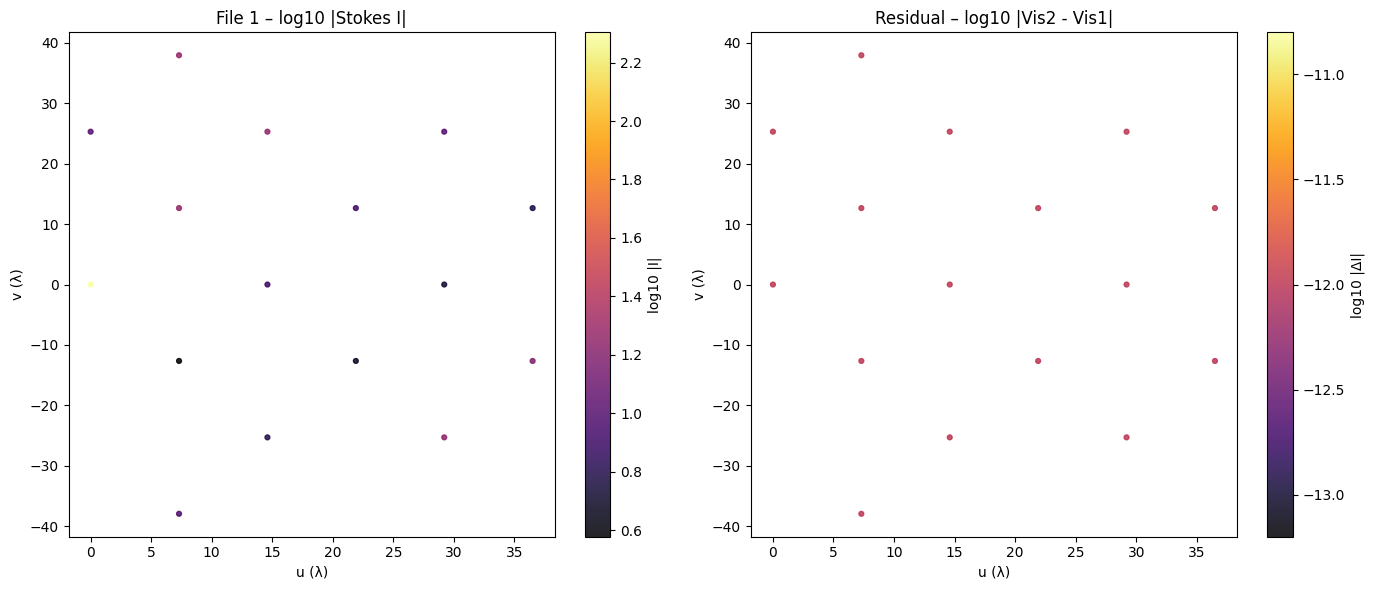

In [54]:

# Input visibility files
file1 = "/home/qdg20/projects/sim_notebook/vis/gleam-158.30-167.10-MHz-nf-38-pld-mean-2.82-std-0.19-fov-19.4deg-circ-field-1_quentin.uvh5"
file2 = "/home/qdg20/projects/sim_notebook/vis/gleam-158.30-167.10-MHz-nf-38-pld-mean-2.82-std-0.19-fov-19.4deg-circ-field-1_quentin.uvh5"

# Load UVData objects
uv1 = UVData()
uv2 = UVData()
uv1.read_uvh5(file1)
uv2.read_uvh5(file2)


def unpack_shape(arr):
    """Extract dimensions from data_array with flexible shape handling."""
    if arr.ndim == 4:
        # (Nblts, Nspws, Nfreq, Npol)
        Nblts, Nspw, Nfreq, Npol = arr.shape
    elif arr.ndim == 3:
        # (Nblts, Nfreq, Npol)
        Nspw = 1
        Nblts, Nfreq, Npol = arr.shape
    else:
        raise ValueError("Unexpected data_array dimension")
    return Nblts, Nspw, Nfreq, Npol


# Get array dimensions
Nbl1, Nspw1, Nfreq1, Npol1 = unpack_shape(uv1.data_array)
Nbl2, Nspw2, Nfreq2, Npol2 = unpack_shape(uv2.data_array)

# Select first timestamp, first frequency, Stokes I
time_idx = 0
freq_idx = 0
pol_idx = 0  # Stokes I

# Create time masks
time_mask1 = uv1.time_array == uv1.time_array[time_idx]
time_mask2 = uv2.time_array == uv2.time_array[time_idx]


def extract_vis(uv, time_mask, freq_idx, pol_idx):
    """Extract visibility slice for given time, frequency, polarization."""
    arr = uv.data_array
    if arr.ndim == 4:
        return arr[time_mask, 0, freq_idx, pol_idx]
    else:
        return arr[time_mask, freq_idx, pol_idx]


# Extract Stokes I visibilities
vis1_I = extract_vis(uv1, time_mask1, freq_idx, pol_idx)
vis2_I = extract_vis(uv2, time_mask2, freq_idx, pol_idx)

# Sort baselines consistently by (ant1, ant2) pairs
keys1 = np.array(list(zip(uv1.ant_1_array[time_mask1], uv1.ant_2_array[time_mask1])), 
                 dtype=[("a1", int), ("a2", int)])
keys2 = np.array(list(zip(uv2.ant_1_array[time_mask2], uv2.ant_2_array[time_mask2])), 
                 dtype=[("a1", int), ("a2", int)])

order1 = np.argsort(keys1, order=("a1", "a2"))
order2 = np.argsort(keys2, order=("a1", "a2"))

vis1_I = vis1_I[order1]
vis2_I = vis2_I[order2]

# Extract UV coordinates
uvw1 = uv1.uvw_array[time_mask1][order1, :2]
uvw2 = uv2.uvw_array[time_mask2][order2, :2]

# Compute residual
residual = np.abs(vis2_I) - np.abs(vis1_I)

# Log-scale for visualization
log_amp1 = np.log10(np.abs(vis1_I) + 1e-12)
log_res = np.log10(np.abs(residual) + 1e-12)

u1, v1 = uvw1[:, 0], uvw1[:, 1]

# Plot visibility amplitude and residual in UV plane
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# File 1 visibility amplitude
sc1 = axes[0].scatter(u1, v1, s=12, c=log_amp1, cmap="inferno", alpha=0.85)
axes[0].set_title("File 1 – log10 |Stokes I|")
axes[0].set_xlabel("u (λ)")
axes[0].set_ylabel("v (λ)")
plt.colorbar(sc1, ax=axes[0], label="log10 |I|")

# Residual
sc2 = axes[1].scatter(u1, v1, s=12, c=log_res, cmap="inferno", alpha=0.85)
axes[1].set_title("Residual – log10 |Vis2 - Vis1|")
axes[1].set_xlabel("u (λ)")
axes[1].set_ylabel("v (λ)")
plt.colorbar(sc2, ax=axes[1], label="log10 |ΔI|")

plt.tight_layout()
plt.show()

## Time-Baseline Waterfall Plot

Visualize visibility amplitudes as a function of time and baseline
for a single frequency channel.

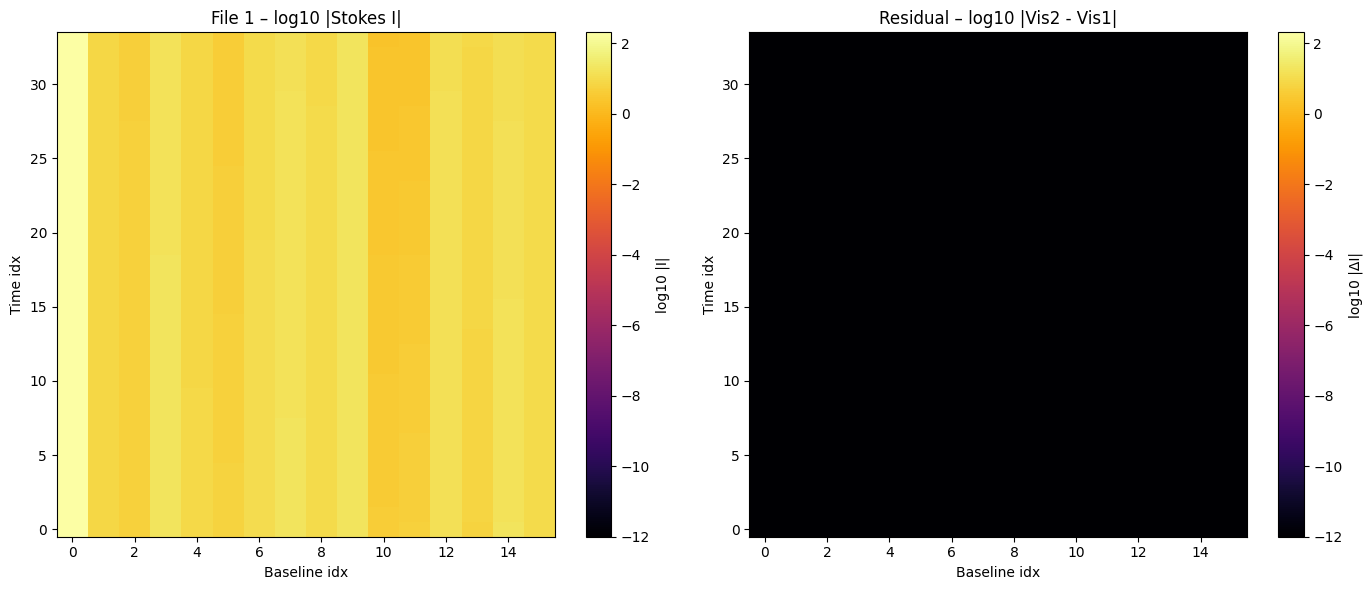

In [57]:
# Choose frequency index and Stokes I
freq_idx = 0
pol_idx = 0

# Extract all time samples for selected frequency
vis1_time = (uv1.data_array[:, 0, freq_idx, pol_idx] if uv1.data_array.ndim == 4 
             else uv1.data_array[:, freq_idx, pol_idx])
vis2_time = (uv2.data_array[:, 0, freq_idx, pol_idx] if uv2.data_array.ndim == 4 
             else uv2.data_array[:, freq_idx, pol_idx])

# Reshape into (time, baseline) matrix
times = np.unique(uv1.time_array)
Ntime = len(times)
Nbl = len(vis1_time) // Ntime

vis1_mat = vis1_time.reshape(Ntime, Nbl)
vis2_mat = vis2_time.reshape(Ntime, Nbl)
residual_mat = np.abs(vis2_mat - vis1_mat)

# Log scaling
eps_val = 1e-12
vis1_log = np.log10(np.abs(vis1_mat) + eps_val)
res_log = np.log10(residual_mat + eps_val)

# Common color scale
clim = [min(vis1_log.min(), res_log.min()), max(vis1_log.max(), res_log.max())]

# Plot waterfall
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# File 1
im1 = axes[0].imshow(vis1_log, aspect='auto', origin='lower', cmap='inferno', 
                      vmin=clim[0], vmax=clim[1])
axes[0].set_title("File 1 – log10 |Stokes I|")
axes[0].set_xlabel("Baseline idx")
axes[0].set_ylabel("Time idx")
plt.colorbar(im1, ax=axes[0], label="log10 |I|")

# Residual
im2 = axes[1].imshow(res_log, aspect='auto', origin='lower', cmap='inferno', 
                      vmin=clim[0], vmax=clim[1])
axes[1].set_title("Residual – log10 |Vis2 - Vis1|")
axes[1].set_xlabel("Baseline idx")
axes[1].set_ylabel("Time idx")
plt.colorbar(im2, ax=axes[1], label="log10 |ΔI|")

plt.tight_layout()
plt.show()

## Frequency-Baseline Waterfall Plot

Visualize visibility amplitudes as a function of frequency and baseline  
for a single timestamp.

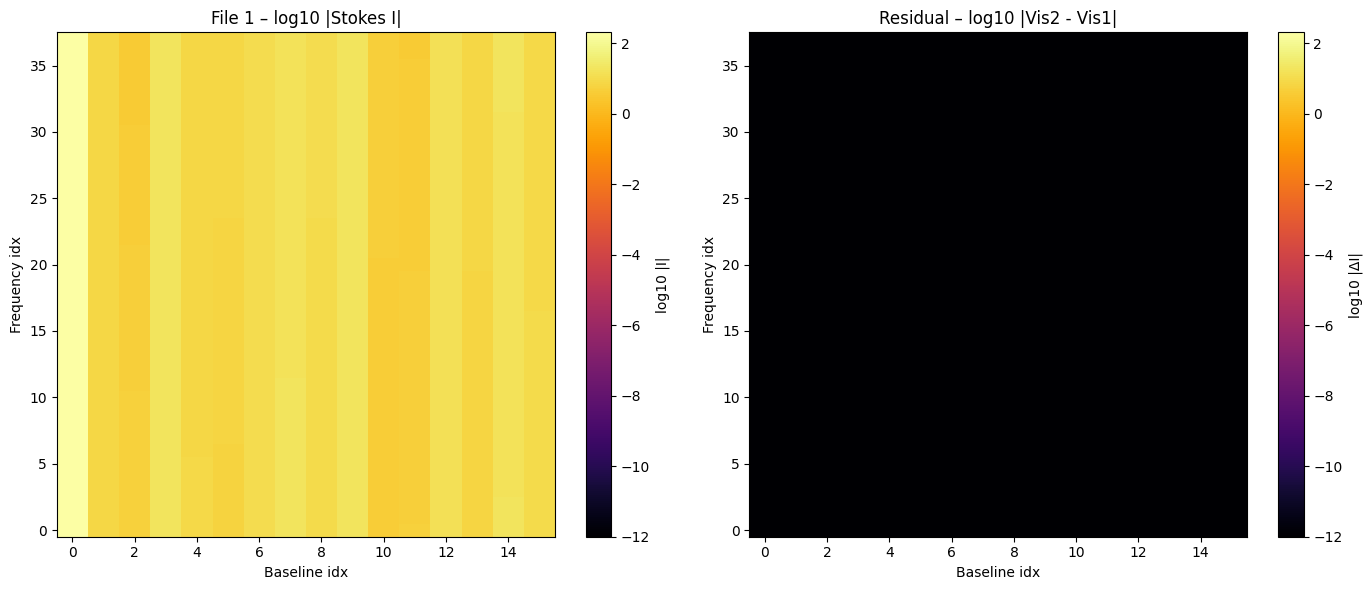

In [56]:
# Choose time index and Stokes I
time_idx = 0
pol_idx = 0


def extract_time_vis(uv, time_idx, pol_idx):
    """Extract visibilities across frequency for a single time."""
    time_mask = uv.time_array == uv.time_array[time_idx]
    if uv.data_array.ndim == 4:
        return uv.data_array[time_mask, 0, :, pol_idx]
    else:
        return uv.data_array[time_mask, :, pol_idx]


# Extract frequency slices (shape: Nbl x Nfreq)
vis1_freq = extract_time_vis(uv1, time_idx, pol_idx)
vis2_freq = extract_time_vis(uv2, time_idx, pol_idx)

# Sort baselines consistently
keys1 = np.array(list(zip(uv1.ant_1_array[uv1.time_array == uv1.time_array[time_idx]],
                          uv1.ant_2_array[uv1.time_array == uv1.time_array[time_idx]])),
                 dtype=[("a1", int), ("a2", int)])
keys2 = np.array(list(zip(uv2.ant_1_array[uv2.time_array == uv2.time_array[time_idx]],
                          uv2.ant_2_array[uv2.time_array == uv2.time_array[time_idx]])),
                 dtype=[("a1", int), ("a2", int)])

order1 = np.argsort(keys1, order=("a1", "a2"))
order2 = np.argsort(keys2, order=("a1", "a2"))

vis1_freq = vis1_freq[order1, :]
vis2_freq = vis2_freq[order2, :]

# Compute residual
residual_freq = np.abs(vis2_freq - vis1_freq)

# Log scaling
eps_val = 1e-12
vis1_log = np.log10(np.abs(vis1_freq) + eps_val)
res_log = np.log10(residual_freq + eps_val)

# Common color scale
clim = [min(vis1_log.min(), res_log.min()), max(vis1_log.max(), res_log.max())]

# Plot frequency waterfall
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# File 1
im1 = axes[0].imshow(vis1_log.T, aspect='auto', origin='lower', cmap='inferno', 
                      vmin=clim[0], vmax=clim[1])
axes[0].set_title("File 1 – log10 |Stokes I|")
axes[0].set_xlabel("Baseline idx")
axes[0].set_ylabel("Frequency idx")
plt.colorbar(im1, ax=axes[0], label="log10 |I|")

# Residual
im2 = axes[1].imshow(res_log.T, aspect='auto', origin='lower', cmap='inferno', 
                      vmin=clim[0], vmax=clim[1])
axes[1].set_title("Residual – log10 |Vis2 - Vis1|")
axes[1].set_xlabel("Baseline idx")
axes[1].set_ylabel("Frequency idx")
plt.colorbar(im2, ax=axes[1], label="log10 |ΔI|")

plt.tight_layout()
plt.show()